In [1]:
import random

import mlflow
import numpy as np
import pyarrow.parquet as pq
import torch.cuda
from torch import nn
from torch.utils.data import Dataset, WeightedRandomSampler, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH = 128
EPOCHS = 30
LR = 1e-3
NUM_CLASSES = 8
DATA_DIR = "../data/processed"

print(f"Device: {DEVICE}")

Device: cuda


In [2]:
LABELS = ["Center", "Donut", "Edge-Loc", "Edge-Ring", "Loc", "Near-full", "Random", "Scratch"]
LABEL2IDX = {name: i for i, name in enumerate(LABELS)}


class WaferDataset(Dataset):
    def __init__(self, parquet_path: str):
        table = pq.read_table(parquet_path)
        df = table.to_pandas()
        wafers = np.stack(df["wafer"].values)
        self.X = wafers.reshape(-1, 1, 64, 64).astype(np.float32)
        self.y = df["label"].map(LABEL2IDX).values.astype(np.int64)
        assert not np.isnan(self.y).any(), "Unknown label found"

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), int(self.y[idx])


train_ds = WaferDataset(f"{DATA_DIR}/train.parquet")
val_ds = WaferDataset(f"{DATA_DIR}/val.parquet")
test_ds = WaferDataset(f"{DATA_DIR}/test.parquet")

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
print(f"X shape={train_ds.X.shape}, dtype={train_ds.X.dtype}")


Train: 17863, Val: 3828, Test: 3828
X shape=(17863, 1, 64, 64), dtype=float32


In [3]:
# count samples per classes in the training set
class_counts = np.bincount(train_ds.y, minlength=NUM_CLASSES)
for i, name in enumerate(LABELS):
    print(f"{name:12s}: {class_counts[i]}")

# Weight per class = inverse frequency -> rare classes get higher weight
class_weights = 1.0 / class_counts
# Assign each sample the weight of its class
sample_weights = class_weights[train_ds.y]
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),  # sampler requires float64
    num_samples=len(sample_weights),  # keep one epoch ~= dataset size
    replacement=True
)

print(f"Sampler ready, {len(sample_weights)} samples")

Center      : 3006
Donut       : 389
Edge-Loc    : 3632
Edge-Ring   : 6776
Loc         : 2515
Near-full   : 104
Random      : 606
Scratch     : 835
Sampler ready, 17863 samples


In [4]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH,
    sampler=sampler,  # weighted sampling -> no shuffle (sample controls order)
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH,
    shuffle=False,  # natural distribution, order irrelevant for eval
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

# Sanity check
xb, yb = next(iter(train_loader))
print(f"batch X: {xb.shape}  {yb.dtype}")  # expect [128, 1, 64, 64] float32
print(f"batch y: {yb.shape}  {yb.dtype}")  # expect [128] int64
print(f"class count in this batch: {np.bincount(yb.numpy(), minlength=NUM_CLASSES)}")

batch X: torch.Size([128, 1, 64, 64])  torch.int64
batch y: torch.Size([128])  torch.int64
class count in this batch: [13 22 17 15 15 14 10 22]


In [6]:
class WaferCNN(nn.Module):
    """Small baseline CNN for 64x64 single channel wafer maps."""

    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            # block 1: 1-> 32, 64x64 -> 32 x 32
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # block 2: 32 -> 64, 32 x 32 -> 16 x 16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # block 3: 64 -> 128, 16 x 16 -> 8 x 8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # 128x8x8 -> 128x1x1, robust to size changes
            nn.Flatten(),  # -> [N, 128]
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = x / 2.0  # normalize die values {0, 1, 2} -> {0, 0.5, 1.0}
        x = self.features(x)
        x = self.classifier(x)
        return x


model = WaferCNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"trainable params: {n_params:,}")

for name, p in model.named_parameters():
    print(f"{name:35s} {str(type(p.shape)):20s} {p.numel():>8,}")

# Forward sanity check on each batch
with torch.no_grad():
    out = model(xb.to(DEVICE))
print(f"output shape: {out.shape}")  # expect [128,8]

WaferCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim

In [7]:
# γ và β init of BatchNorm — weight = γ, bias = β
bn = model.features[1]  # BatchNorm2d(32)
print("γ (weight):", bn.weight.data[:5])  # all 1.0
print("β (bias):  ", bn.bias.data[:5])  # all 0.0

# He-init randomly
conv = model.features[0]  # Conv2d(1, 32)
print("conv weight:", conv.weight.data[0, 0])  # 3×3 random small number

γ (weight): tensor([1., 1., 1., 1., 1.], device='cuda:0')
β (bias):   tensor([0., 0., 0., 0., 0.], device='cuda:0')
conv weight: tensor([[-0.1274,  0.1385,  0.1792],
        [ 0.3243, -0.0250,  0.2116],
        [ 0.0672, -0.2570, -0.1777]], device='cuda:0')


In [8]:
from pathlib import Path

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam, a solid default for CNNs
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Mlflow: point to a local tracking dir and name the experiment
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
db_path = PROJECT_ROOT / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_experiment("wm811k-baseline-cnn")

print("criterion, optimizer, and experiment set up!")

criterion, optimizer, and experiment set up!


In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()  # enable Dropout + BatchNorm use batch stats
    running_loss = 0.0
    n_samples = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()  # clear gradients from previous step
        logits = model(xb)  # forward
        loss = criterion(logits, yb)  # how wrong
        loss.backward()  # backprop: compute gradients
        optimizer.step()  # nudge parameters

        running_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)
    return running_loss / n_samples


@torch.no_grad()  # no gradients needed for eval -> faster, less memory
def evaluate(model, loader, criterion, device):
    model.eval()  # disables Dropout + BatchNorm uses running stats
    running_loss = 0.0
    n_samples = 0
    all_preds, all_labels = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)

        running_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)
        all_preds.append(logits.argmax(dim=1).cpu())
        all_labels.append(yb.cpu())

    avg_loss = running_loss / n_samples
    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    return avg_loss, preds, labels


print("train/eval functions ready!")

train/eval functions ready!


In [11]:
# Macro-F1: unweighted mean over classes -> rare classes count equally
from sklearn.metrics import f1_score

best_val_loss = float("inf")
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)
FIGURE_DIR = PROJECT_ROOT / "docs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
best_path = MODEL_DIR / "wafercnn_best.pt"

# # Params logged once per run for reproducibility
# run_params = {
#     "model": "WaferCNN",
#     "epochs": EPOCHS,
#     "batch_size": BATCH,
#     "lr": LR,
#     "optimizer": "Adam",
#     "loss": "CrossEntropyLoss",
#     "sampler": "WeightedRandomSampler",
#     "seed": SEED,
#     "img_size": 64,
#     "num_classes": NUM_CLASSES,
# }
#
# with mlflow.start_run(run_name="baseline-cnn"):
#     mlflow.log_params(run_params)
#     for epoch in range(1, EPOCHS + 1):
#         train_loss = train_one_epoch(model=model, loader=train_loader, criterion=criterion, optimizer=optimizer,
#                                      device=DEVICE)
#         val_loss, val_preds, val_labels = evaluate(model=model, loader=val_loader, criterion=criterion, device=DEVICE)
#         val_macro_f1 = f1_score(y_true=val_labels, y_pred=val_preds, average="macro")
#
#         mlflow.log_metrics(
#             metrics={
#                 "train_loss": train_loss,
#                 "val_loss": val_loss,
#                 "val_macro_f1": val_macro_f1,
#             }, step=epoch
#         )
#
#         print(
#             f"epoch {epoch:2d} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | val macro-F1: {val_macro_f1:.4f}")
#
#         # Save the best by val_loss
#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             torch.save(model.state_dict(), best_path)
#             mlflow.log_artifact(str(best_path))
#             print(f"\t-> saved best (val_loss {val_loss:.4f})")
#
# print(f"\nDone! Best val_loss: {best_val_loss:.4f}")

epoch  1 | train loss: 1.1165 | val loss: 1.1518 | val macro-F1: 0.5049
	-> saved best (val_loss 1.1518)
epoch  2 | train loss: 0.8209 | val loss: 0.8252 | val macro-F1: 0.6074
	-> saved best (val_loss 0.8252)
epoch  3 | train loss: 0.7115 | val loss: 0.8070 | val macro-F1: 0.5886
	-> saved best (val_loss 0.8070)
epoch  4 | train loss: 0.6566 | val loss: 1.0714 | val macro-F1: 0.4704
epoch  5 | train loss: 0.6093 | val loss: 0.6106 | val macro-F1: 0.6956
	-> saved best (val_loss 0.6106)
epoch  6 | train loss: 0.5753 | val loss: 0.8421 | val macro-F1: 0.4945
epoch  7 | train loss: 0.5431 | val loss: 1.7085 | val macro-F1: 0.4710
epoch  8 | train loss: 0.5235 | val loss: 1.0748 | val macro-F1: 0.4631
epoch  9 | train loss: 0.4873 | val loss: 0.9440 | val macro-F1: 0.5881
epoch 10 | train loss: 0.4601 | val loss: 0.4974 | val macro-F1: 0.7422
	-> saved best (val_loss 0.4974)
epoch 11 | train loss: 0.4394 | val loss: 0.5444 | val macro-F1: 0.7274
epoch 12 | train loss: 0.4294 | val loss: 0

Test loss: 0.3824
              precision    recall  f1-score   support

      Center      0.777     0.908     0.838       644
       Donut      0.750     0.759     0.754        83
    Edge-Loc      0.788     0.935     0.855       779
   Edge-Ring      0.993     0.947     0.969      1452
         Loc      0.764     0.492     0.598       539
   Near-full      0.957     1.000     0.978        22
      Random      0.936     0.792     0.858       130
     Scratch      0.728     0.821     0.772       179

    accuracy                          0.859      3828
   macro avg      0.836     0.832     0.828      3828
weighted avg      0.863     0.859     0.854      3828



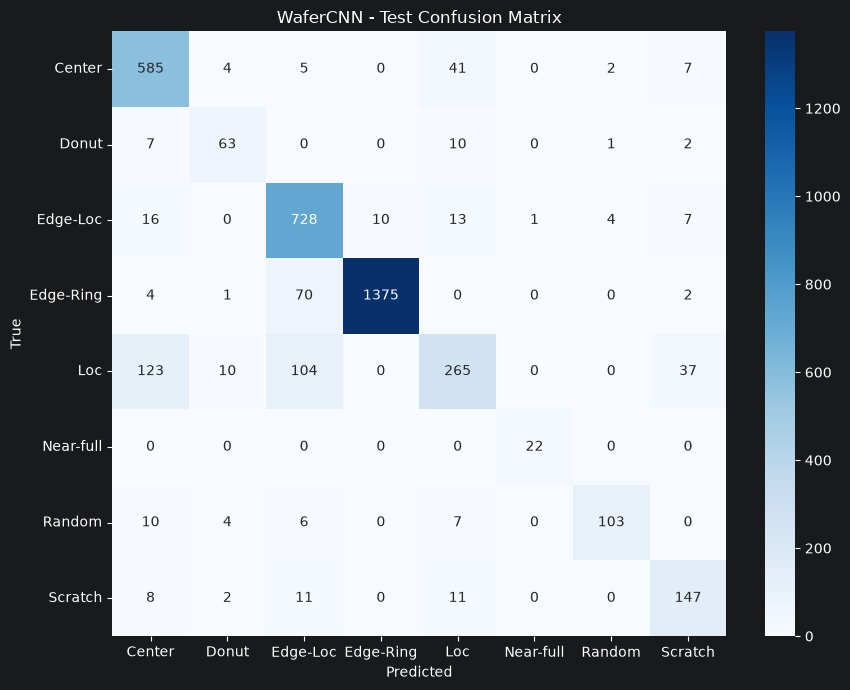

In [12]:
# from sklearn.metrics import classification_report, confusion_matrix
# import matplotlib.pyplot as plt
# import seaborn as sns
#
# # Load the best checkpoint, not the last-epoch weights
# model.load_state_dict(torch.load(best_path, map_location=DEVICE))
#
# # Evaluate once on the held-out test set
# test_loss, test_preds, test_labels = evaluate(model=model, loader=test_loader, criterion=criterion, device=DEVICE)
# print(f"Test loss: {test_loss:.4f}")
#
# # Per class precision, recall, and F1 - the real evaluation
# print(classification_report(y_true=test_labels, y_pred=test_preds, target_names=LABELS, digits=3))
#
# # Confusion matrix
# cm = confusion_matrix(y_true=test_labels, y_pred=test_preds)
# plt.figure(figsize=(9, 7))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
#
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("WaferCNN - Test Confusion Matrix")
# plt.tight_layout()
#
# cm_path = FIGURE_DIR / "confusion_matrix_wafercnn_test.png"
# plt.savefig(cm_path, dpi=120, bbox_inches="tight")
# plt.show()

# Baseline model Diagnosis & Next steps
The baseline CNN reaches **macro-F1 0.828 / accuracy 0.859** on the held-out test set, with **test loss 0.3824** across 3,828 test wafers. The full macro averages are **precision 0.836 / recall 0.832 / F1 0.828**, and weighted F1 is **0.854**. This is a healthy starting point for a ~94k-param model trained from scratch. The confusion matrix reveals where it actually struggles, which updates the earlier diagnosis.

### What the confusion matrix shows

**1. Rare classes are not the problem.**

Near-full (the rarest class, 22 test samples) has **precision 0.957 / recall 1.000 / F1 0.978** - the model misses none of them and rarely over-predicts it. Random also performs well (**F1 0.858**, 130 samples). This confirms `WeightedRandomSampler` is working as expected: oversampling gave the rare classes enough signal to be learned.

**2. The real weakness is Loc recall.**

Loc is the weakest class (**precision 0.764 / recall 0.492 / F1 0.598**). Out of 539 true Loc wafers, only 265 are predicted correctly; the largest misses are **Loc → Center (123)**, **Loc → Edge-Loc (104)**, and **Loc → Scratch (37)**. Center itself is now strong (**recall 0.908**, F1 0.838), so the old Center→Loc diagnosis no longer matches the current run.

**3. Edge-region classes still overlap.**

Edge-Loc is strong overall (**recall 0.935**, F1 0.855), and Edge-Ring is the best high-support class (**F1 0.969**). The main edge-region confusion is **Edge-Ring → Edge-Loc (70)**, with a smaller **Edge-Loc → Edge-Ring (10)**. Geometrically, this is reasonable because both are edge-region defects with similar shapes.

### Diagnosing the val_loss instability

During training, `val_loss` oscillated sharply. The current confusion matrix rules out the rare-class hypothesis: the small classes are well-classified, so the instability is **global oscillation**, not noise from tiny class supports. The likely root cause is a **fixed learning rate (1e-3) that stays too high late in training** - large update steps can make the model bounce around the optimum instead of settling.

### Three possible directions

| Option                            | What it does                                                                    | Cost    | When                                          |
|-----------------------------------|---------------------------------------------------------------------------------|---------|-----------------------------------------------|
| **A. LR scheduler**               | Reduce LR when val_loss stalls → smoother convergence, possibly higher macro-F1 | ~10 min | **Now** — diagnosis points to LR instability |
| **B. ResNet-18 from scratch**     | Higher capacity may resolve Loc boundary confusion on its own                   | longer  | After baseline is finalized                  |
| **C. Inspect Loc misses**         | Visualize Loc→Center, Loc→Edge-Loc, and Loc→Scratch examples                    | short   | Better handled later via Grad-CAM            |

We proceed with **Option A first** (cheap, diagnosis-aligned), keeping the original run for a
clean before/after comparison in MLflow, then move to Option B (ResNet-18) with a solid,
finalized baseline as the comparison anchor.

### Why ReduceLROnPlateau (not a fixed schedule)

`ReduceLROnPlateau` watches val_loss and only lowers the LR when improvement stalls — it reacts
to the actual training signal rather than following a predetermined curve. This directly targets
the observed symptom (val_loss plateauing then bouncing), which is the principled choice given
what the diagnosis showed.


In [13]:
# Fresh model + optimizer so this run trains from scratch. Class is still defined once in the above cell.
model = WaferCNN().to(device=DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode="min", factor=0.5,
                                                       patience=3)  # LR scheduler: halve learning rate after val_loss stalls for 3 epochs

run_params = {
    "model": "WaferCNN",
    "epochs": EPOCHS,
    "batch_size": BATCH,
    "lr": LR,
    "optimizer": "Adam",
    "loss": "CrossEntropyLoss",
    "sampler": "WeightedRandomSampler",
    "scheduler": "ReduceLROnPlateau(factor=0.5, patience=3)",
    "seed": SEED,
    "img_size": 64,
    "num_classes": NUM_CLASSES,
}

# with mlflow.start_run(run_name="baseline-cnn-scheduler"):
#     mlflow.log_params(run_params)
#     for epoch in range(1, EPOCHS + 1):
#         train_loss = train_one_epoch(model=model, loader=train_loader, criterion=criterion, optimizer=optimizer,
#                                      device=DEVICE)
#         val_loss, val_preds, val_labels = evaluate(model=model, loader=val_loader, criterion=criterion, device=DEVICE)
#         scheduler.step(val_loss)
#         val_macro_f1 = f1_score(y_true=val_labels, y_pred=val_preds, average="macro")
#         scheduler.step(val_loss)  # feed val_loss to scheduler
#         current_lr = optimizer.param_groups[0]["lr"]
#
#         mlflow.log_metrics(
#             metrics={
#                 "train_loss": train_loss,
#                 "val_loss": val_loss,
#                 "val_macro_f1": val_macro_f1,
#                 "lr": current_lr,
#             }, step=epoch
#         )
#         print(
#             f"epoch {epoch:2d} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | val macro-F1: {val_macro_f1:.4f} | lr: {current_lr:.4f}")
#
#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             torch.save(model.state_dict(), best_path)
#             mlflow.log_artifact(str(best_path))
#             print(f"\t-> saved best (val_loss {val_loss:.4f})")
#
# print(f"\nDone! Best val_loss: {best_val_loss:.4f}")

epoch  1 | train loss: 1.1085 | val loss: 1.2840 | val macro-F1: 0.3843 | lr: 0.0010
epoch  2 | train loss: 0.8202 | val loss: 1.2942 | val macro-F1: 0.4810 | lr: 0.0010
epoch  3 | train loss: 0.7150 | val loss: 0.8757 | val macro-F1: 0.5498 | lr: 0.0010
epoch  4 | train loss: 0.6538 | val loss: 0.7355 | val macro-F1: 0.5933 | lr: 0.0010
epoch  5 | train loss: 0.6085 | val loss: 0.9121 | val macro-F1: 0.5874 | lr: 0.0010
epoch  6 | train loss: 0.5819 | val loss: 0.6615 | val macro-F1: 0.7097 | lr: 0.0010
epoch  7 | train loss: 0.5374 | val loss: 0.6412 | val macro-F1: 0.6131 | lr: 0.0010
epoch  8 | train loss: 0.5296 | val loss: 0.5746 | val macro-F1: 0.6872 | lr: 0.0010
epoch  9 | train loss: 0.4870 | val loss: 0.8588 | val macro-F1: 0.6715 | lr: 0.0010
epoch 10 | train loss: 0.4801 | val loss: 1.8613 | val macro-F1: 0.4296 | lr: 0.0005
epoch 11 | train loss: 0.4371 | val loss: 0.4610 | val macro-F1: 0.7790 | lr: 0.0005
epoch 12 | train loss: 0.4123 | val loss: 0.5995 | val macro-F1: 

Test loss: 0.3824
              precision    recall  f1-score   support

      Center      0.777     0.908     0.838       644
       Donut      0.750     0.759     0.754        83
    Edge-Loc      0.788     0.935     0.855       779
   Edge-Ring      0.993     0.947     0.969      1452
         Loc      0.764     0.492     0.598       539
   Near-full      0.957     1.000     0.978        22
      Random      0.936     0.792     0.858       130
     Scratch      0.728     0.821     0.772       179

    accuracy                          0.859      3828
   macro avg      0.836     0.832     0.828      3828
weighted avg      0.863     0.859     0.854      3828



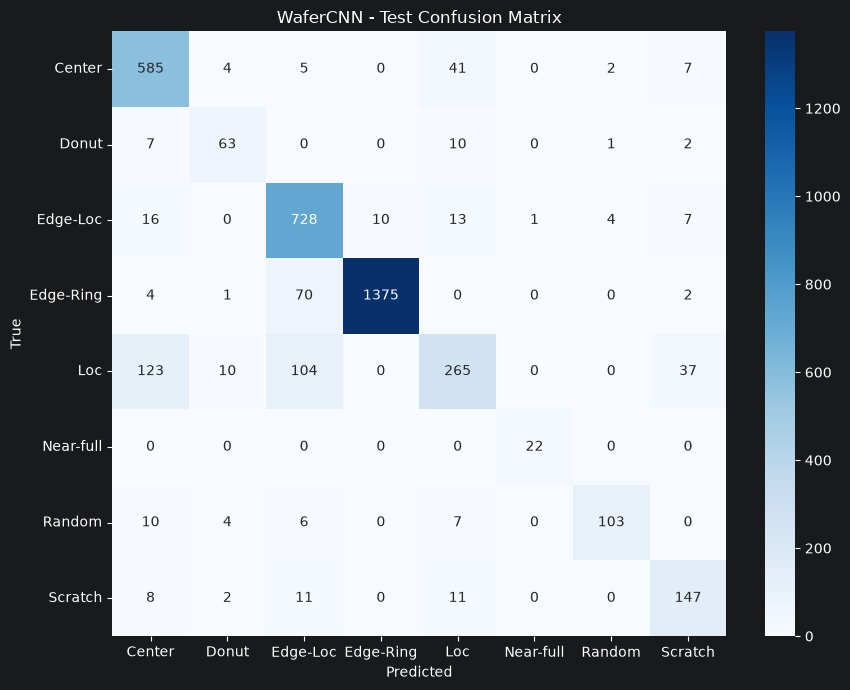

In [14]:
# # Load the best checkpoint, not the last-epoch weights
# model.load_state_dict(torch.load(best_path, map_location=DEVICE))
#
# # Evaluate once on the held-out test set
# test_loss, test_preds, test_labels = evaluate(model=model, loader=test_loader, criterion=criterion, device=DEVICE)
# print(f"Test loss: {test_loss:.4f}")
#
# # Per class precision, recall, and F1 - the real evaluation
# print(classification_report(y_true=test_labels, y_pred=test_preds, target_names=LABELS, digits=3))
#
# # Confusion matrix
# cm = confusion_matrix(y_true=test_labels, y_pred=test_preds)
# plt.figure(figsize=(9, 7))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
#
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("WaferCNN - Test Confusion Matrix")
# plt.tight_layout()
#
# cm_path = FIGURE_DIR / "confusion_matrix_wafercnn_scheduler_test.png"
# plt.savefig(cm_path, dpi=120, bbox_inches="tight")
# plt.show()

In [15]:
def run_experiment(model, run_name, train_loader, val_loader, epochs=EPOCHS, lr=LR, es_patience=7):
    """Train a model with Mlflow logging, LR scheduling, and early stopping. Returns the path to the best checkpoint by val_loss"""
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode="min", factor=0.5, patience=3)
    best_val_loss = float("inf")
    epochs_no_improve = 0
    MODEL_DIR.mkdir(exist_ok=True)
    best_path = MODEL_DIR / f"{run_name}_best.pt"
    run_params = {
        "model": run_name,
        "epochs": epochs,
        "batch_size": BATCH,
        "lr": lr,
        "optimizer": "Adam",
        "loss": "CrossEntropyLoss",
        "sampler": "WeightedRandomSampler",
        "scheduler": "ReduceLROnPlateau(factor=0.5, patience=3)",
        "early_stopping_patience": es_patience,
        "seed": SEED,
        "img_size": 64,
        "num_classes": NUM_CLASSES,
    }

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(run_params)
        for epoch in range(1, epochs + 1):
            train_loss = train_one_epoch(model=model, loader=train_loader, criterion=criterion, optimizer=optimizer,
                                         device=DEVICE)
            val_loss, val_preds, val_labels = evaluate(model=model, loader=val_loader, criterion=criterion,
                                                       device=DEVICE)
            val_macro_f1 = f1_score(y_true=val_labels, y_pred=val_preds, average="macro")

            scheduler.step(metrics=val_loss)
            current_lr = optimizer.param_groups[0]["lr"]

            mlflow.log_metrics(
                {"train_loss": train_loss, "val_loss": val_loss, "val_macro_f1": val_macro_f1, "lr": current_lr},
                step=epoch)

            print(
                f"epoch {epoch:2d} | train {train_loss:.4f} | val_loss {val_loss:.4f} | val_macro-F1: {val_macro_f1:.4f} | lr: {current_lr:.2e}")

            # track the best + early stopping counter
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
                torch.save(model.state_dict(), best_path)
                mlflow.log_artifact(str(best_path))
                print(f"\t-> saved best (val_loss {val_loss:.4f})")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= es_patience:
                    print(f"\t-> early stopping at epoch {epoch} (no improvement for {epochs_no_improve} epochs)")
                    break
    print(f"Done! Best val_loss: {best_val_loss:.4f}")
    return best_path

In [16]:
def evaluate_and_report(best_path, model, loader, title, device=DEVICE):
    """Load best checkpoint, run per-class report + confusion matrix on loader"""
    model = model.to(device=device)
    model.load_state_dict(torch.load(best_path, map_location=device))
    test_loss, test_preds, test_labels = evaluate(model=model, loader=loader, criterion=criterion, device=device)
    print(f"Test loss for {title}: {test_loss:.4f}")
    print(classification_report(y_true=test_labels, y_pred=test_preds, target_names=LABELS, digits=3))

    cm = confusion_matrix(y_true=test_labels, y_pred=test_preds)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{title} - Test Confusion Matrix")
    plt.tight_layout()

    cm_filenames = {
        "CNN (test, augmented)": "confusion_matrix_cnn_aug_test.png",
        "ResNet18 (test)": "confusion_matrix_resnet18_test.png",
        "ResNet18 (test, augmented)": "confusion_matrix_resnet18_aug_test.png",
    }
    safe_title = "_".join("".join(ch if ch.isalnum() else " " for ch in title.lower()).split())
    cm_path = FIGURE_DIR / cm_filenames.get(title, f"confusion_matrix_{safe_title}.png")
    plt.savefig(cm_path, dpi=120, bbox_inches="tight")
    plt.show()
    # print(f"Saved confusion matrix to {cm_path}")
    return cm_path


In [15]:
# cnn = WaferCNN()
# cnn_best_path = run_experiment(model=cnn, run_name="baseline-cnn-scheduler-earlystop", train_loader=train_loader,
#                                val_loader=val_loader)
# _ = evaluate_and_report(best_path=cnn_best_path, model=cnn, loader=test_loader,
#                         title="Baseline CNN, LR scheduler, Early stopping")

In [16]:
# def run_experiment_f1(model, run_name, train_loader, val_loader, epochs=EPOCHS, lr=LR, es_patience=7):
#     """Train a model with Mlflow logging, LR scheduling, and early stopping. Returns the path to the best checkpoint by val macro-F1"""
#     model = model.to(DEVICE)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode="min", factor=0.5, patience=3)
#     best_val_f1 = -float("inf")
#     epochs_no_improve = 0
#     MODEL_DIR.mkdir(exist_ok=True)
#     best_path = MODEL_DIR / f"{run_name}_best.pt"
#     run_params = {
#         "model": run_name,
#         "epochs": epochs,
#         "batch_size": BATCH,
#         "lr": lr,
#         "optimizer": "Adam",
#         "loss": "CrossEntropyLoss",
#         "sampler": "WeightedRandomSampler",
#         "scheduler": "ReduceLROnPlateau(factor=0.5, patience=3)",
#         "early_stopping_patience": es_patience,
#         "seed": SEED,
#         "img_size": 64,
#         "num_classes": NUM_CLASSES,
#     }
#
#     with mlflow.start_run(run_name=run_name):
#         mlflow.log_params(run_params)
#         for epoch in range(1, epochs + 1):
#             train_loss = train_one_epoch(model=model, loader=train_loader, criterion=criterion, optimizer=optimizer,
#                                          device=DEVICE)
#             val_loss, val_preds, val_labels = evaluate(model=model, loader=val_loader, criterion=criterion,
#                                                        device=DEVICE)
#             val_macro_f1 = f1_score(y_true=val_labels, y_pred=val_preds, average="macro")
#
#             scheduler.step(metrics=val_loss)  # scheduler react to loss not F1
#             current_lr = optimizer.param_groups[0]["lr"]
#
#             mlflow.log_metrics(
#                 {"train_loss": train_loss, "val_loss": val_loss, "val_macro_f1": val_macro_f1, "lr": current_lr},
#                 step=epoch
#             )
#
#             print(
#                 f"epoch {epoch:2d} | train {train_loss:.4f} | val_loss {val_loss:.4f} | val_macro-F1: {val_macro_f1:.4f} | lr: {current_lr:.2e}"
#             )
#
#             # track the best + early stopping counter
#             if val_macro_f1 > best_val_f1:
#                 best_val_f1 = val_macro_f1
#                 epochs_no_improve = 0
#                 torch.save(model.state_dict(), best_path)
#                 mlflow.log_artifact(str(best_path))
#                 print(f"\t-> saved best (val_macro-F1 {val_macro_f1:.4f})")
#             else:
#                 epochs_no_improve += 1
#                 if epochs_no_improve >= es_patience:
#                     print(f"\t-> early stopping at epoch {epoch} (no improvement for {epochs_no_improve} epochs)")
#                     break
#
#     print(f"Done! Best val_macro-F1: {best_val_f1:.4f}")
#     return best_path

In [17]:
# cnn = WaferCNN()
# cnn_best_path = run_experiment(
#     model=cnn,
#     run_name="baseline-cnn-scheduler-earlystop-f1",
#     train_loader=train_loader,
#     val_loader=val_loader,
#     epochs=50,
#     es_patience=15,
# )
# _ = evaluate_and_report(
#     best_path=cnn_best_path,
#     model=cnn,
#     loader=test_loader,
#     title="Baseline CNN, LR scheduler, Early stopping, F1",
# )

In [18]:
# def run_experiment_f1_checkpoint_only(
#         model, run_name, train_loader, val_loader, epochs=EPOCHS, lr=LR, es_patience=7
# ):
#     """Train a model with Mlflow logging, LR scheduling, and early stopping. Returns the path to the best checkpoint by val macro-F1"""
#     model = model.to(DEVICE)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#         optimizer=optimizer, mode="min", factor=0.5, patience=3
#     )
#     best_val_f1 = -float("inf")
#     best_val_loss = float("inf")
#     epochs_no_improve = 0
#     MODEL_DIR.mkdir(exist_ok=True)
#     best_path = MODEL_DIR / f"{run_name}_best.pt"
#     run_params = {
#         "model": run_name,
#         "epochs": epochs,
#         "batch_size": BATCH,
#         "lr": lr,
#         "optimizer": "Adam",
#         "loss": "CrossEntropyLoss",
#         "sampler": "WeightedRandomSampler",
#         "scheduler": "ReduceLROnPlateau(factor=0.5, patience=3)",
#         "early_stopping_patience": es_patience,
#         "seed": SEED,
#         "img_size": 64,
#         "num_classes": NUM_CLASSES,
#     }
#
#     with mlflow.start_run(run_name=run_name):
#         mlflow.log_params(run_params)
#         for epoch in range(1, epochs + 1):
#             train_loss = train_one_epoch(
#                 model=model,
#                 loader=train_loader,
#                 criterion=criterion,
#                 optimizer=optimizer,
#                 device=DEVICE,
#             )
#             val_loss, val_preds, val_labels = evaluate(
#                 model=model, loader=val_loader, criterion=criterion, device=DEVICE
#             )
#             val_macro_f1 = f1_score(
#                 y_true=val_labels, y_pred=val_preds, average="macro"
#             )
#
#             scheduler.step(metrics=val_loss)  # scheduler react to loss not F1
#             current_lr = optimizer.param_groups[0]["lr"]
#
#             mlflow.log_metrics(
#                 {
#                     "train_loss": train_loss,
#                     "val_loss": val_loss,
#                     "val_macro_f1": val_macro_f1,
#                     "lr": current_lr,
#                 },
#                 step=epoch,
#             )
#
#             print(
#                 f"epoch {epoch:2d} | train {train_loss:.4f} | val_loss {val_loss:.4f} | val_macro-F1: {val_macro_f1:.4f} | lr: {current_lr:.2e}"
#             )
#
#             # track the best macro-F1 to save the best model
#             if val_macro_f1 > best_val_f1:
#                 best_val_f1 = val_macro_f1
#                 torch.save(model.state_dict(), best_path)
#                 mlflow.log_artifact(str(best_path))
#                 print(f"\t-> saved best (val_macro-F1 {val_macro_f1:.4f})")
#
#             # track the best val_loss to update the early stopping counter
#             if val_loss < best_val_loss:
#                 best_val_loss = val_loss
#                 epochs_no_improve = 0
#                 print(f"\t-> saved best (val_loss {val_loss:.4f})")
#             else:
#                 epochs_no_improve += 1
#                 if epochs_no_improve >= es_patience:
#                     print(
#                         f"\t-> early stopping at epoch {epoch} (no improvement for {epochs_no_improve} epochs)"
#                     )
#                     break
#
#     print(f"Done! Best val_macro-F1: {best_val_f1:.4f}")
#     return best_path

In [19]:
# cnn = WaferCNN()
# cnn_best_path = run_experiment_f1_checkpoint_only(
#     model=cnn,
#     run_name="baseline-cnn-scheduler-f1-checkpoint-only",
#     train_loader=train_loader,
#     val_loader=val_loader,
#     epochs=50,
#     es_patience=15,
# )
# _ = evaluate_and_report(
#     best_path=cnn_best_path,
#     model=cnn,
#     loader=test_loader,
#     title="Baseline CNN, LR scheduler, F1, checkpoint only",
# )

In [17]:
import torch.nn as nn
import torch.nn.functional as F


class BasicBlock(nn.Module):
    """Standard ResNet BasicBlock: two 3x3 conv with a residual connection
    The skip connection is the whole point of ResNet: it lets the gradient flow directly past the conv layers (identity path), so deep networks stay trainable instead of degrading. expansion=1 means output channels == `out_channels`
    """
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        # First conv carries the stride: this is where spatial downsampling happens
        # at the start of stages 2/3/4 (stride=2). padding=1 keep 3x3 size-preserving
        # when stride=1. bias=False because BN right after subtracts the mean,
        # which cancels any constant bias - BN beta does the shifting instead.
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        # BatchNorm3d(c): keep one (mean, var) pair per output channel computed over batch (batch x H x W)
        # plus one learnable (gamma, beta) pair per channel
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, stride=1, padding=1,
                               bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # down sample: a 1x1 conv (+BN) applied to the identity shortcut, use only when the
        # shortcut's shape doesn't match the main path - i.e. channels changed or
        # stride halved the spatial size. Without it, `out + identity` crashes on
        # shape mismatch. Built by _make_layer and passed in (None for most blocks).
        self.downsample = downsample

    def forward(self, x):
        identity = x

        # Main path: conv -> BN -> ReLU, then conv -> BN (no ReLU yet)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # Match the shorcut's shape to out if needed.
        if self.downsample is not None:
            identity = self.downsample(x)

        # The residual add, then ReLU (post activation)
        # ReLU comes after the add so the identity signal passes through un-clipped
        out += identity
        return F.relu(out)


In [18]:
class WaferResNet18(nn.Module):
    """ResNet-18 from scratch for 1-channel 64x64 wafer maps, 8 classes.
    Deviations from the ImageNet original:
        - Stem is a 3x3 stride-1 conv, no maxpool (ImageNet uses 7x7 stride-2 + maxpool, which downsamples 4x immediately -- too aggressive for a 64x64 input)
        - conv1 takes 1 input channel (wafer is single-channel), fc outputs 8 classes. The core (BasicBlock, [2,2,2,2] layout, 64->128->256->512, stride-2 stage starts) is standard ResNet-18
    """

    def __init__(self, num_classes=NUM_CLASSES, in_channels=1):
        super().__init__()
        # Running channel count while BUILDING the network. Starts at 64 because that's how many channels exist right after the stem, _make_layer reads and updates it.
        self.in_channels = 64

        # Stem: 1 -> 64 channels, keeps 64x64 (kernel 3 + padding 1, stride 1)
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        # 4 stages, each = num_blocks BasicBlock. Spatial 64->64->32->16->8
        self.layer1 = self._make_layer(out_channels=64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(out_channels=128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(out_channels=256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(out_channels=512, num_blocks=2, stride=2)

        # Head: pool each channel's 8x8 map to a single number, then classify.
        self.avgpool = nn.AdaptiveAvgPool2d(1)  # 512x8x8 -> 512x1x1
        self.fc = nn.Linear(in_features=512, out_features=num_classes)  # 512 -> 8

        self._init_weights()

    def _make_layer(self, out_channels, num_blocks, stride):
        """Build of stage of num_blocks BasicBlock. Only the FIRST block may change shape (it carries the stride and/or the channel change), so only it may need a downsample on its shortcut. The remaining blocks are stride-1, same-channel -> no-downsample
        """
        downsample = None
        # A projection shortcut is needed only if the shortcut's shape won't match the main path
        # either the spatial size shrinks (stride!=1) or the channel count change (self.in_channels != self.out_channels)
        if stride != 1 or self.in_channels != out_channels * BasicBlock.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels=self.in_channels, out_channels=out_channels * BasicBlock.expansion, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * BasicBlock.expansion),
            )

        # First block: uses the incoming self.in_channels, applies stride + downsample
        layers = [
            BasicBlock(in_channels=self.in_channels, out_channels=out_channels, stride=stride, downsample=downsample)]
        # After the first block the running channel count becomes out_channels
        self.in_channels = out_channels * BasicBlock.expansion
        # Remaining blocks: in == out channels, stride 1, no downsample
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(in_channels=self.in_channels, out_channels=out_channels))
        return nn.Sequential(*layers)

    def _init_weights(self):
        """Kaiming init for conv weights matches ReLU, standard BN init"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Same normalization as WaferCNN, so the architecture comparison stays clean
        x = x / 2.0  # discrete {0,1,2} -> {0,0.5,1.0}
        # Stem
        x = F.relu(self.bn1(self.conv1(x)))

        # 4 stages
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [20]:
# sanity check
_test_model = WaferResNet18().to(DEVICE)
_dummy = torch.randn(4, 1, 64, 64, device=DEVICE)  # batch=4, 1 channel, 64x64
with torch.no_grad():
    _out = _test_model(_dummy)
print(f"Output shape: {_out.shape} (expect torch.Size([4, {NUM_CLASSES}]))")

n_params = sum(p.numel() for p in _test_model.parameters())
print(f"Total params: {n_params:,} (expect ~11.2M for ResNet-18)")
del _test_model, _dummy, _out

Output shape: torch.Size([4, 8]) (expect torch.Size([4, 8]))
Total params: 11,171,784 (expect ~11.2M for ResNet-18)


In [21]:
resnet_best_path = run_experiment(WaferResNet18(), "resnet18-scratch", train_loader, val_loader)

epoch  1 | train 0.7269 | val_loss 0.7814 | val_macro-F1: 0.6591 | lr: 1.00e-03
	-> saved best (val_loss 0.7814)
epoch  2 | train 0.3701 | val_loss 0.6289 | val_macro-F1: 0.6890 | lr: 1.00e-03
	-> saved best (val_loss 0.6289)
epoch  3 | train 0.2442 | val_loss 0.3359 | val_macro-F1: 0.8315 | lr: 1.00e-03
	-> saved best (val_loss 0.3359)
epoch  4 | train 0.1727 | val_loss 1.0259 | val_macro-F1: 0.6920 | lr: 1.00e-03
epoch  5 | train 0.1291 | val_loss 0.5655 | val_macro-F1: 0.7782 | lr: 1.00e-03
epoch  6 | train 0.1328 | val_loss 0.5363 | val_macro-F1: 0.8055 | lr: 1.00e-03
epoch  7 | train 0.0956 | val_loss 0.5957 | val_macro-F1: 0.7942 | lr: 5.00e-04
epoch  8 | train 0.0555 | val_loss 0.2809 | val_macro-F1: 0.8813 | lr: 5.00e-04
	-> saved best (val_loss 0.2809)
epoch  9 | train 0.0310 | val_loss 0.2718 | val_macro-F1: 0.8930 | lr: 5.00e-04
	-> saved best (val_loss 0.2718)
epoch 10 | train 0.0271 | val_loss 0.2877 | val_macro-F1: 0.8774 | lr: 5.00e-04
epoch 11 | train 0.0207 | val_loss 

Test loss for ResNet18 (test): 0.2874
              precision    recall  f1-score   support

      Center      0.914     0.977     0.944       644
       Donut      0.892     0.699     0.784        83
    Edge-Loc      0.922     0.852     0.886       779
   Edge-Ring      0.983     0.979     0.981      1452
         Loc      0.820     0.844     0.832       539
   Near-full      0.875     0.955     0.913        22
      Random      0.890     0.931     0.910       130
     Scratch      0.762     0.821     0.790       179

    accuracy                          0.919      3828
   macro avg      0.882     0.882     0.880      3828
weighted avg      0.920     0.919     0.919      3828



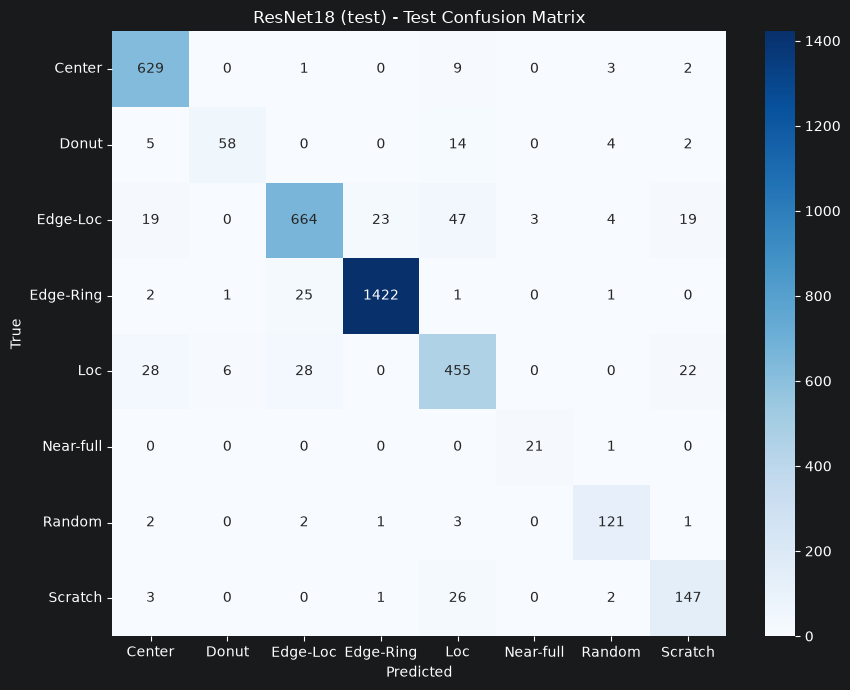

In [22]:
_ = evaluate_and_report(resnet_best_path, WaferResNet18(), test_loader, "ResNet18 (test)")

In [23]:
class AugmentedWaferDataset(WaferDataset):
    """WaferDataset + on-the-fly geometric augmentation, for Training only
    Inherits all data loading (Parquet -> RAM, reshape, label map) from WaferDataset;
    only __getitem__ is overridden to apply a random discrete-safe transform.
    Domain-safe by construction:
        - Only 90/180/270 rotation + flips. These PERMUTE pixels (never interpolate) so discrete {0,1,2} values are preserved exactly -- no off-grid values.
        - Transforms are about the center, so edge-vs-center is preserved (a Center defect never drifts toward the edge -- unlike crop/translate).
    NEVER wrap val/test in this class --evaluation must see raw data.
    """

    def __getitem__(self, idx):
        # Un-augmented sample from the parent: (tensor [1,64,64], int label)
        x, y = super().__getitem__(idx=idx)

        # Random rotation by k*90 degrees (k in {0,1,2,3}). rot90 only permutes pixels
        k = torch.randint(low=0, high=4, size=(1,)).item()
        if k > 0:
            x = torch.rot90(input=x, k=k, dims=(1, 2))

        # Random horizontal flip (50%)
        if torch.rand(1).item() < 0.5:
            x = torch.flip(input=x, dims=(-1,))  # Flip along the width

        # Random vertical flip (50%)
        if torch.rand(1).item() < 0.5:
            x = torch.flip(input=x, dims=(-2,))  # Flip along the height

        # rot90/flip return non-contiguous views; make contiguous so the Dataloader collate and downstream ops get a clean tensor
        return x.contiguous(), y

In [24]:
train_ds_aug = AugmentedWaferDataset(f"{DATA_DIR}/train.parquet")
train_loader_aug = DataLoader(
    dataset=train_ds_aug,
    batch_size=BATCH,
    sampler=sampler
)
print(f"Augmented train dataset: {len(train_ds_aug)} samples, batch size {BATCH}")

Augmented train dataset: 17863 samples, batch size 128


epoch  1 | train 0.7825 | val_loss 0.5180 | val_macro-F1: 0.7205 | lr: 1.00e-03
	-> saved best (val_loss 0.5180)
epoch  2 | train 0.4791 | val_loss 0.5226 | val_macro-F1: 0.7022 | lr: 1.00e-03
epoch  3 | train 0.3604 | val_loss 0.5823 | val_macro-F1: 0.7351 | lr: 1.00e-03
epoch  4 | train 0.3140 | val_loss 0.5614 | val_macro-F1: 0.7077 | lr: 1.00e-03
epoch  5 | train 0.2645 | val_loss 0.2720 | val_macro-F1: 0.8583 | lr: 1.00e-03
	-> saved best (val_loss 0.2720)
epoch  6 | train 0.2406 | val_loss 0.3048 | val_macro-F1: 0.8478 | lr: 1.00e-03
epoch  7 | train 0.2374 | val_loss 0.2333 | val_macro-F1: 0.8779 | lr: 1.00e-03
	-> saved best (val_loss 0.2333)
epoch  8 | train 0.2192 | val_loss 0.3988 | val_macro-F1: 0.8130 | lr: 1.00e-03
epoch  9 | train 0.2086 | val_loss 0.3237 | val_macro-F1: 0.7944 | lr: 1.00e-03
epoch 10 | train 0.1896 | val_loss 0.2857 | val_macro-F1: 0.8551 | lr: 1.00e-03
epoch 11 | train 0.2000 | val_loss 0.3024 | val_macro-F1: 0.8410 | lr: 5.00e-04
epoch 12 | train 0.14

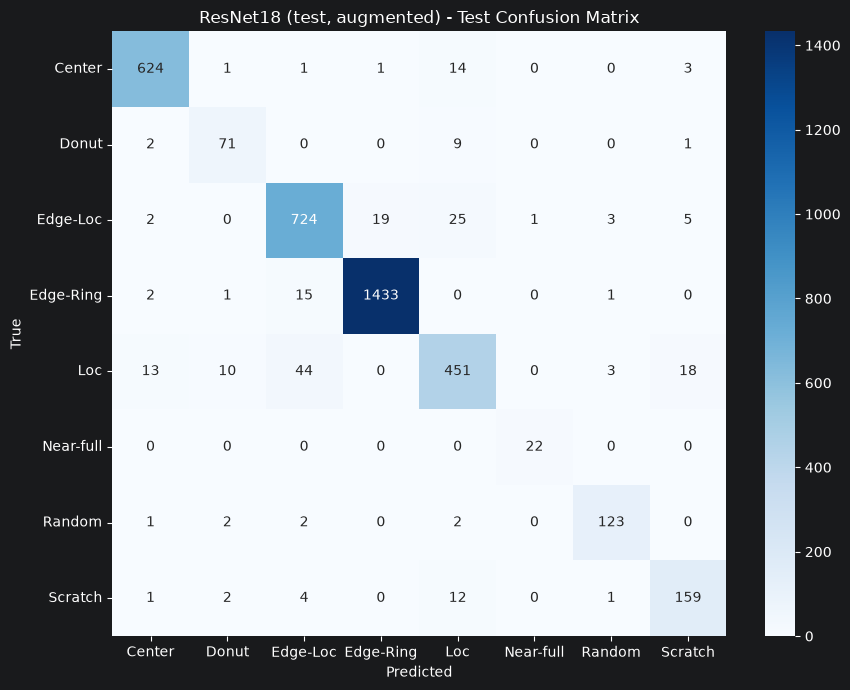

In [25]:
resnet_aug_best_path = run_experiment(model=WaferResNet18(), run_name="resnet18-aug", train_loader=train_loader_aug,
                                      val_loader=val_loader)
_ = evaluate_and_report(best_path=resnet_aug_best_path, model=WaferResNet18(), loader=test_loader,
                        title="ResNet18 (test, augmented)")

In [26]:
# cnn_aug_best_path = run_experiment(model=WaferCNN(), run_name="cnn-aug", train_loader=train_loader_aug,
#                                    val_loader=val_loader)
# _ = evaluate_and_report(best_path=cnn_aug_best_path, model=WaferCNN(), loader=test_loader,
#                         title="CNN (test, augmented)")